# Mounting Google Drive & Dataset Extraction

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Install unrar
!apt-get install unrar -y

# Create target directory and extract the dataset
!mkdir -p /content/dataset
!unrar x -y "/content/drive/My Drive/CMATERdb 3.1.2.rar" "/content/dataset/"


Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal

Cannot open /content/drive/My Drive/CMATERdb 3.1.2.rar
No such file or directory
No files to extract


# Importing Libraries

In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import os
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Model

# Bengali Character Mapping

In [ ]:
bengali_char_map = {
    0: "অ", 1: "আ", 2: "ই", 3: "ঈ", 4: "উ", 5: "ঊ", 6: "ঋ", 7: "এ", 8: "ঐ", 9: "ও", 10: "ঔ",
    11: "ক", 12: "খ", 13: "গ", 14: "ঘ", 15: "ঙ", 16: "চ", 17: "ছ", 18: "জ", 19: "ঝ", 20: "ঞ",
    21: "ট", 22: "ঠ", 23: "ড", 24: "ঢ", 25: "ণ", 26: "ত", 27: "থ", 28: "দ", 29: "ধ", 30: "ন",
    31: "প", 32: "ফ", 33: "ব", 34: "ভ", 35: "ম", 36: "য", 37: "র", 38: "ল", 39: "শ", 40: "ষ",
    41: "স", 42: "হ", 43: "ড়", 44: "ঢ়", 45: "য়", 46: "ৎ", 47: "ং", 48: "ঃ", 49: "ঁ"
}


# Image Preprocessing Function

In [ ]:
def load_and_preprocess_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print(f"Warning: Unable to read image at {image_path}")
        return None
    image = cv2.resize(image, (32,32))  # Resize to a fixed size
    image = image / 255.0  # Normalize pixel values
    image = np.expand_dims(image, axis=-1)  # Add channel dimension
    return image

# Dataset Loading Function

In [ ]:
def load_dataset(dataset_path):
    images = []
    labels = []
    class_names = sorted(os.listdir(dataset_path))
    valid_extensions = ('.bmp', '.png', '.jpg', '.jpeg')  # Add other valid extensions if needed
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(dataset_path, class_name)
        for image_name in os.listdir(class_path):
            if image_name.lower().endswith(valid_extensions):
                image_path = os.path.join(class_path, image_name)
                image = load_and_preprocess_image(image_path)
                if image is not None:
                    images.append(image)
                    labels.append(label)
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32), class_names


In [ ]:
# Dataset paths
train_dataset_path = '/content/dataset/BasicFinalDatabase/Train'
test_dataset_path = '/content/dataset/BasicFinalDatabase/Test'

train_images, train_labels, train_class_names = load_dataset(train_dataset_path)
test_images, test_labels, test_class_names = load_dataset(test_dataset_path)


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

def build_cnn_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # Convolution Block 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Convolution Block 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Convolution Block 3
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Flatten and Dense Layers
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


In [ ]:
from sklearn.model_selection import train_test_split
train_images1, X_vali, train_labels1, y_vali = train_test_split(train_images, train_labels, test_size=0.1, random_state=42)

In [ ]:
# Build Model
input_shape = (32, 32, 1)  # Height, Width, Channels
num_classes = len(train_class_names)  # Number of unique Bengali letters
model = build_ann_model(input_shape, num_classes)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 50)                  │           6,450 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 695,474 (2.65 MB)

 Trainable params: 695,474 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(train_images, train_labels, epochs=100, batch_size=32, validation_data=(X_vali, y_vali))

# Evaluate the model
model.evaluate(test_images, test_labels)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.0778 - loss: 3.6505 - val_accuracy: 0.3850 - val_loss: 2.2114
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.3873 - loss: 2.2081 - val_accuracy: 0.5417 - val_loss: 1.7230
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5116 - loss: 1.7329 - val_accuracy: 0.6083 - val_loss: 1.3969
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5719 - loss: 1.4980 - val_accuracy: 0.6258 - val_loss: 1.2870
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6235 - loss: 1.3087 - val_accuracy: 0.6750 - val_loss: 1.1015
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6667 - loss: 1.1397 - val_accuracy: 0.7017 - val_loss: 1.0041
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7014 - loss: 0.9978 - val_accuracy: 0.7583 - val_loss: 0.8002
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7377 - loss: 0.8759 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predicted label: 38, Predicted text: ল


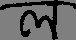

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Predict text from a new image
new_image_path = '/content/dataset/BasicFinalDatabase/Train/210/bcc000000.bmp'
new_image = load_and_preprocess_image(new_image_path)

if new_image is not None:
    prediction = model.predict(np.expand_dims(new_image, axis=0))
    predicted_label = np.argmax(prediction)

    # Get the Bengali character using the mapping dictionary
    predicted_text = bengali_char_map.get(predicted_label, "Unknown")

    print(f"Predicted label: {predicted_label}, Predicted text: {predicted_text}")

    # Display the image using OpenCV
    img = cv2.imread(new_image_path)
    cv2_imshow(img)

else:
    print("Unable to read the new image.")

In [ ]:


import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Function to plot correlation matrix
def plot_correlation_matrix(y_true, y_pred, class_names):
    conf_matrix = confusion_matrix(y_true, y_pred)
    corr_matrix = np.corrcoef(conf_matrix)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=class_names, yticklabels=class_names)
    plt.title("Correlation Matrix of Bengali Characters")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Function to plot ROC curve
def plot_roc_curve(y_true, y_pred_probs, num_classes):
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

    plt.figure(figsize=(10, 8))

    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "k--")  # Random guessing line
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve for Bengali Character Classification")
    plt.legend()
    plt.show()

# Predict on test set
y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


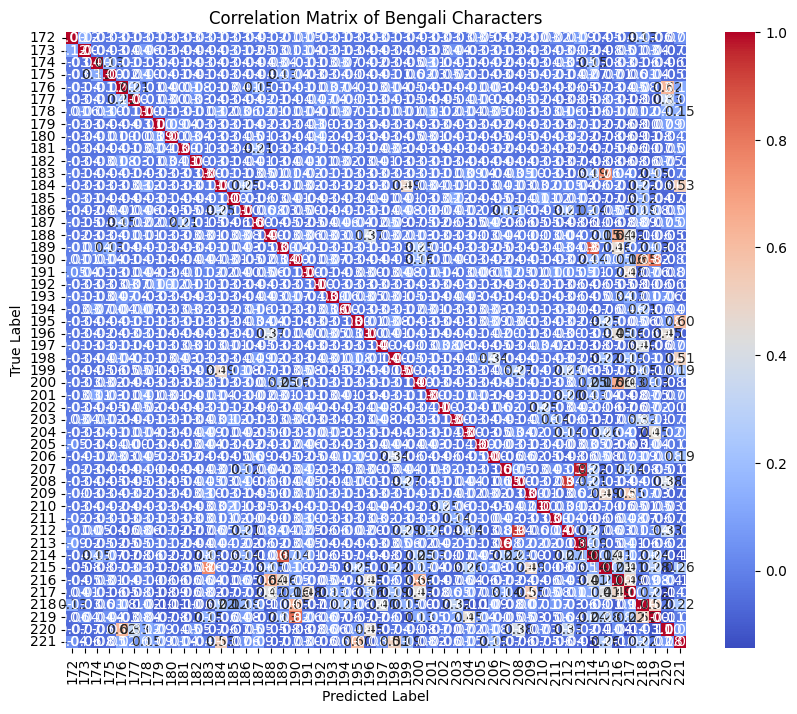

In [ ]:
plot_correlation_matrix(test_labels, y_pred, train_class_names)

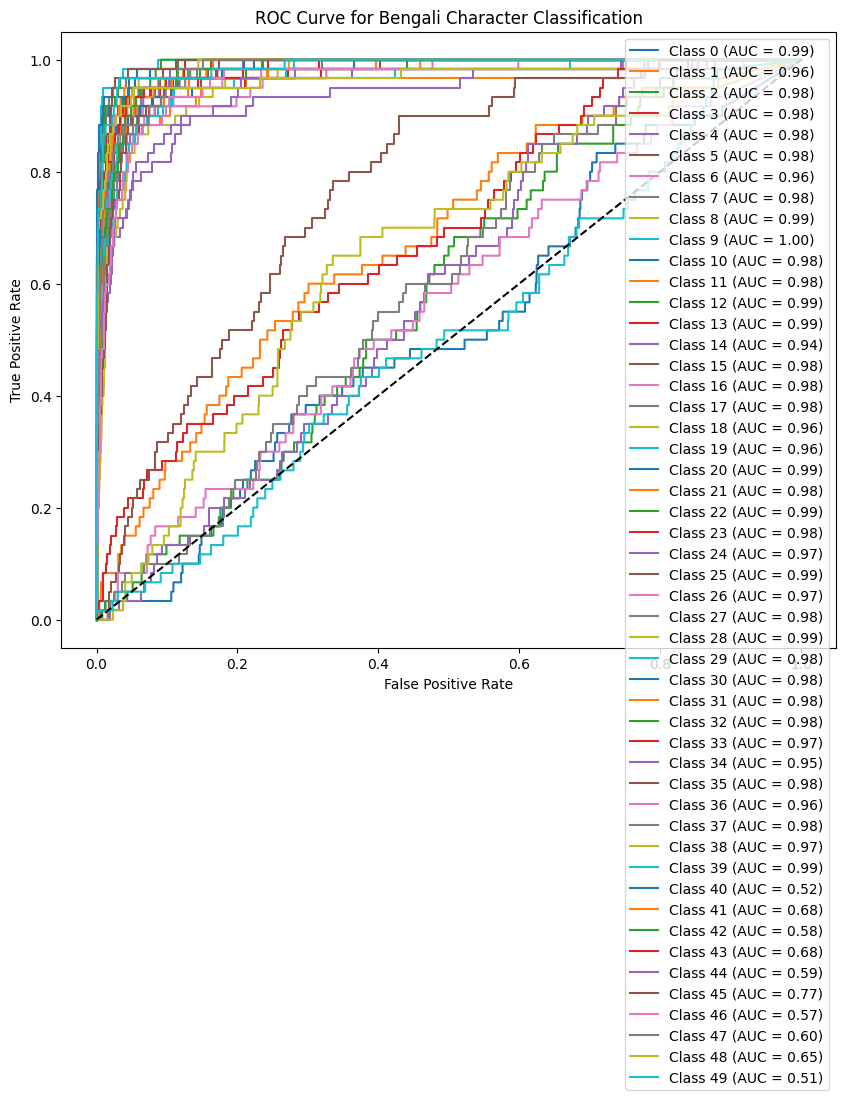

In [ ]:
plot_roc_curve(test_labels, y_pred_probs, len(train_class_names))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
